In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/hillstrom_data.csv")

In [7]:
print(f"Shape: {df.shape}")
print("\nSummary Statistics:")
print(df.describe())
print("\nNulls:")
print(df.isnull().sum())
print("\nHead:")
print(df.head())

Shape: (64000, 12)

Summary Statistics:
            recency       history          mens        womens        newbie  \
count  64000.000000  64000.000000  64000.000000  64000.000000  64000.000000   
mean       5.763734    242.085656      0.551031      0.549719      0.502250   
std        3.507592    256.158608      0.497393      0.497526      0.499999   
min        1.000000     29.990000      0.000000      0.000000      0.000000   
25%        2.000000     64.660000      0.000000      0.000000      0.000000   
50%        6.000000    158.110000      1.000000      1.000000      1.000000   
75%        9.000000    325.657500      1.000000      1.000000      1.000000   
max       12.000000   3345.930000      1.000000      1.000000      1.000000   

              visit    conversion         spend  
count  64000.000000  64000.000000  64000.000000  
mean       0.146781      0.009031      1.050908  
std        0.353890      0.094604     15.036448  
min        0.000000      0.000000      0.000000 

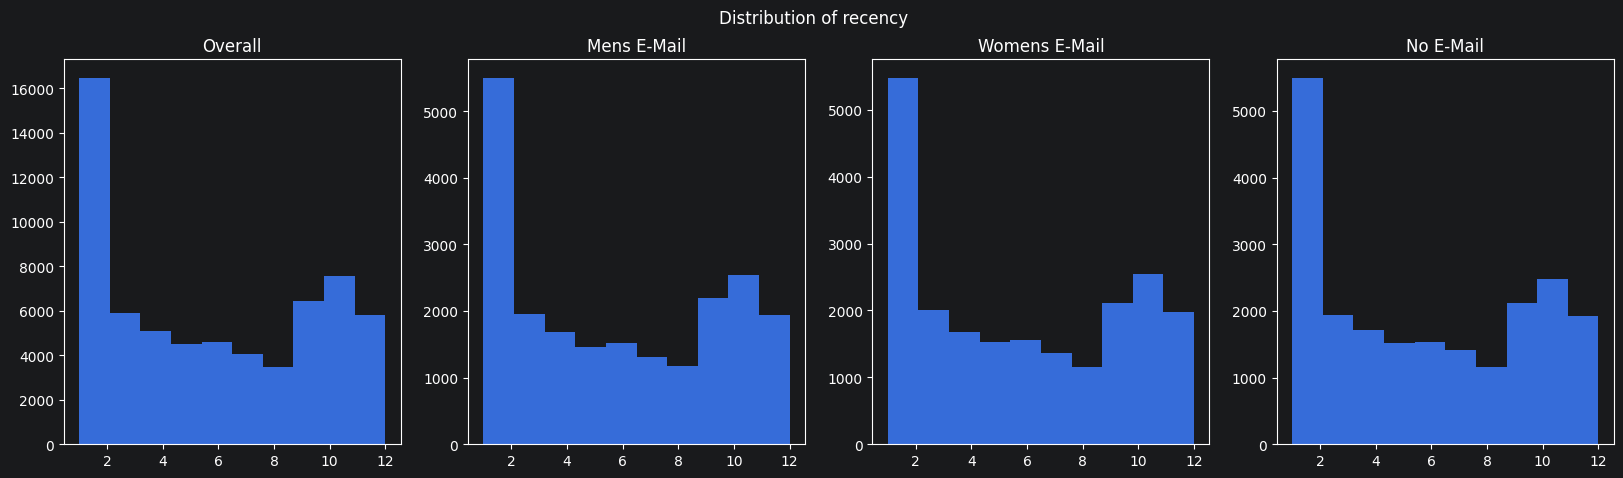

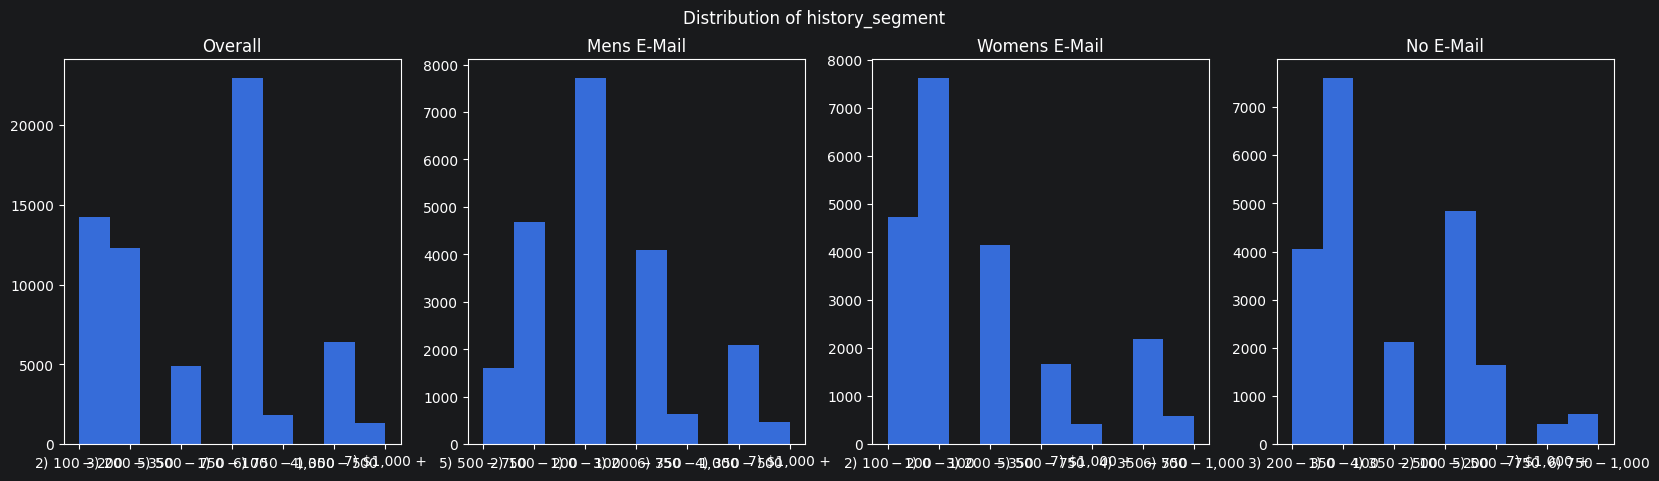

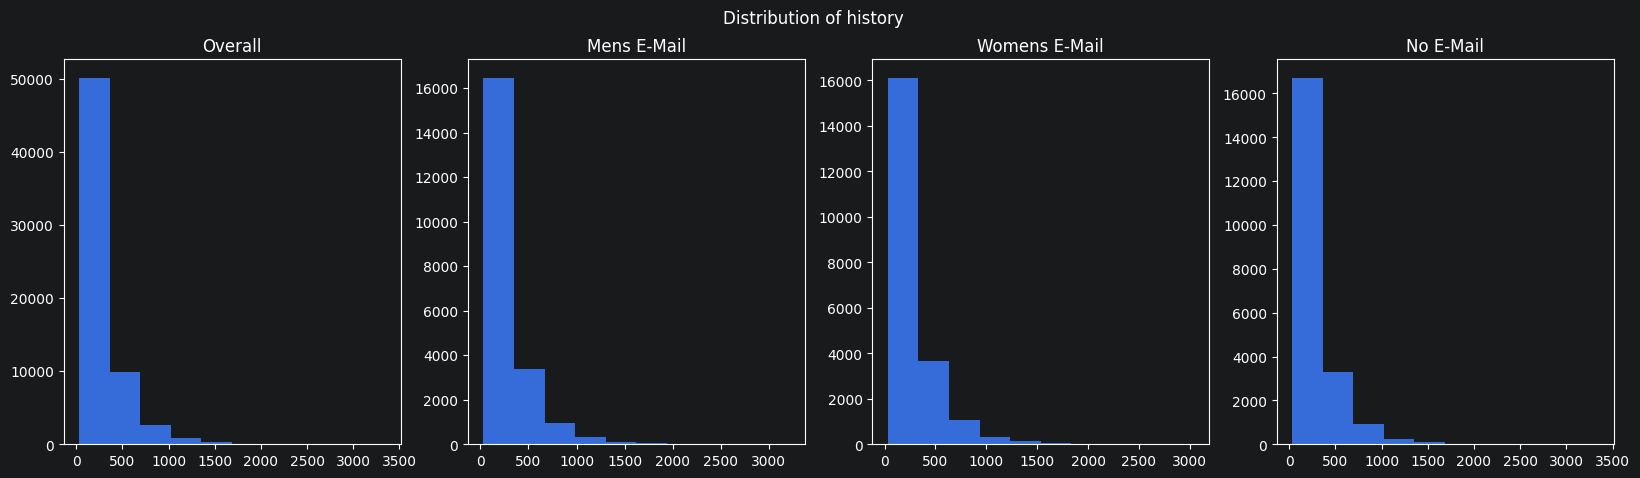

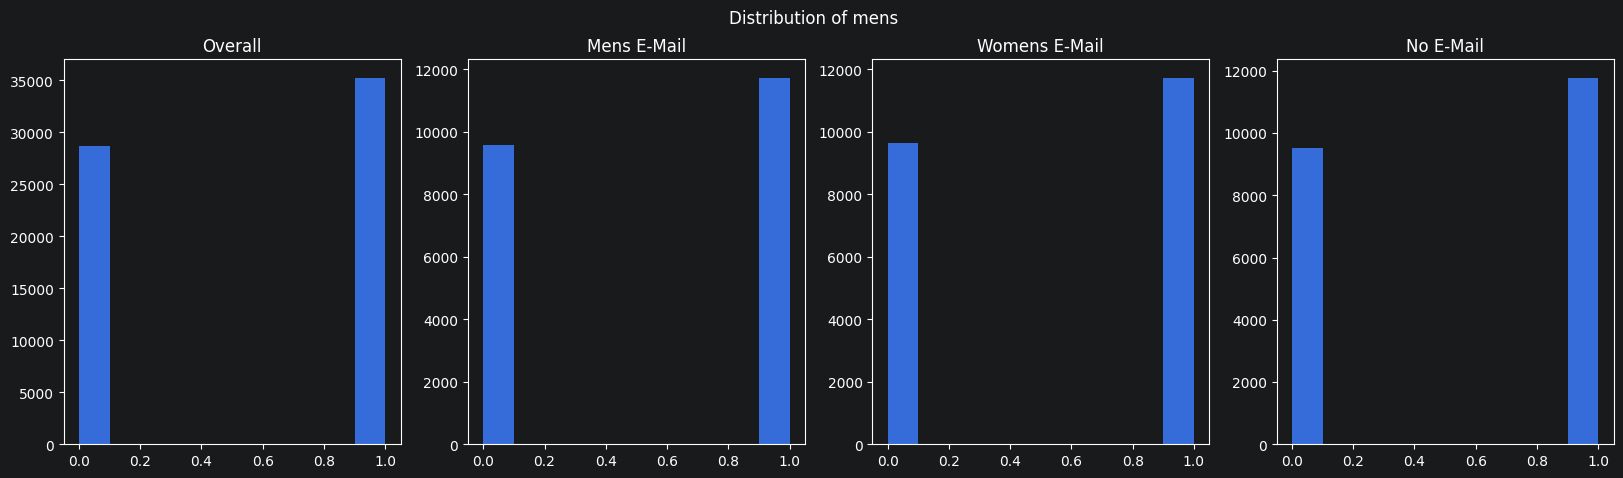

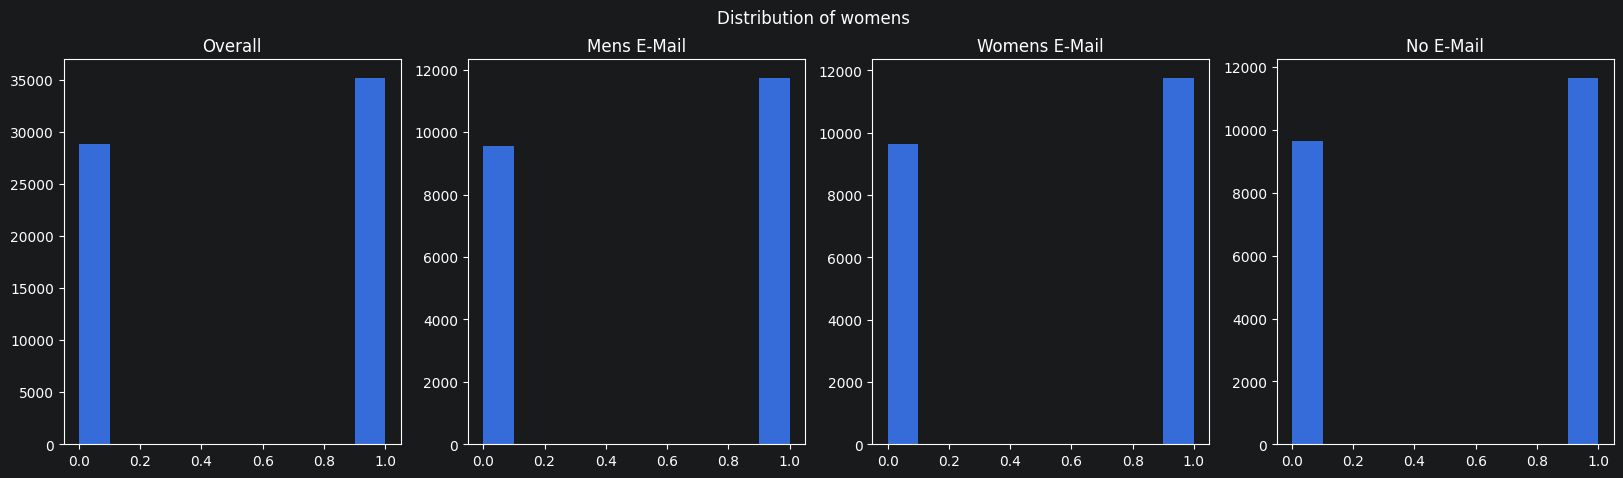

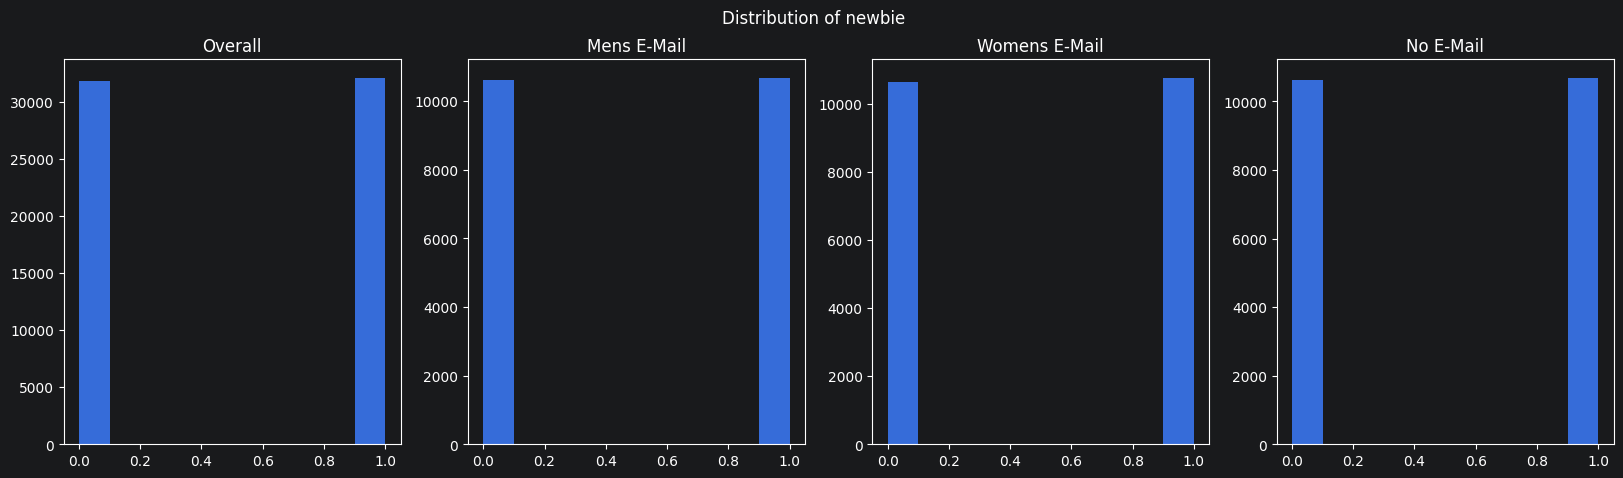

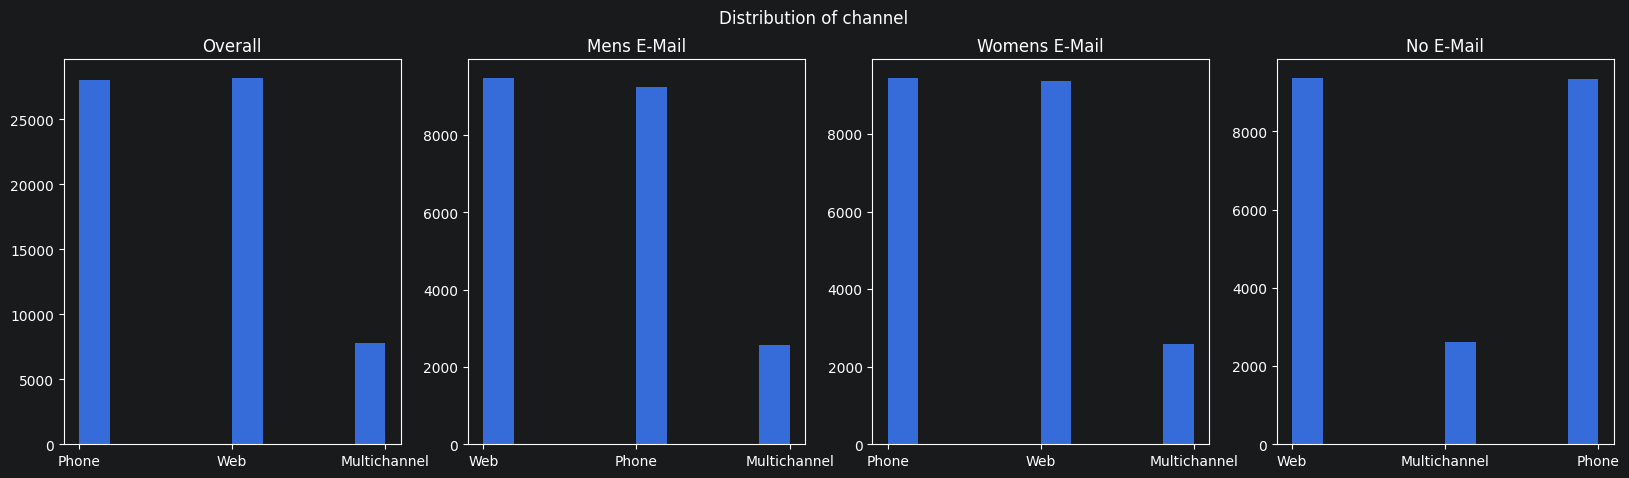

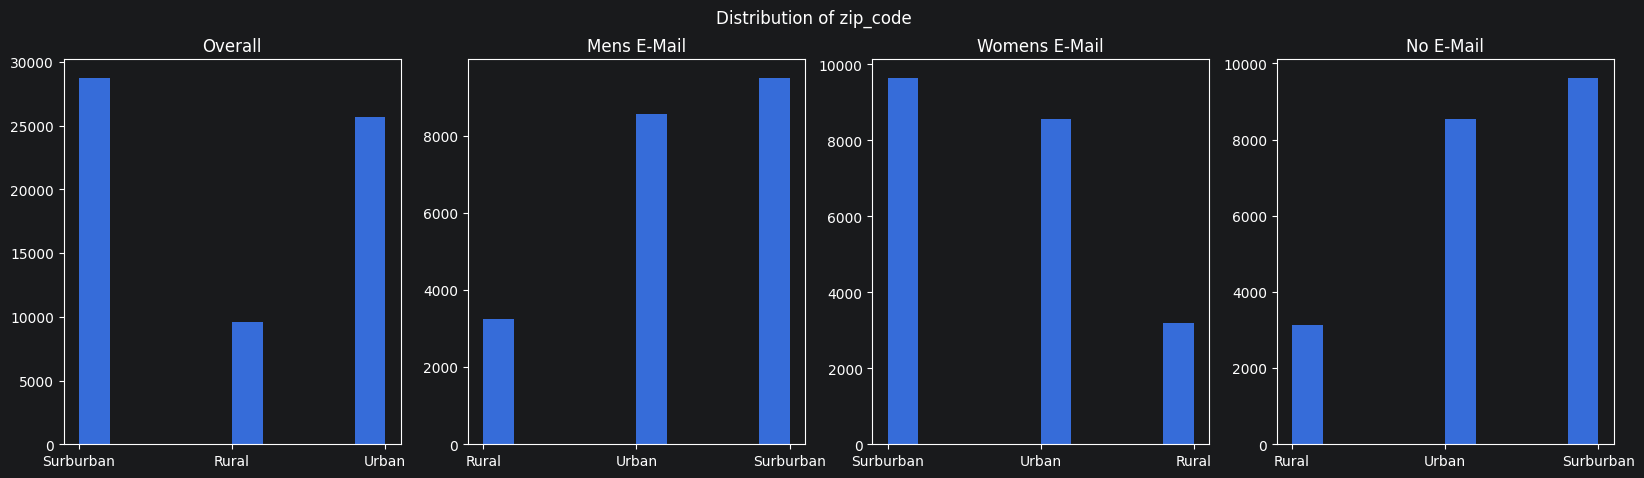

               channel
segment               
Mens E-Mail      21307
No E-Mail        21306
Womens E-Mail    21387


In [64]:
# Verify randomization by checking distribution of covariates

df_men_email = df[df["segment"] == "Mens E-Mail"].copy()
df_women_email = df[df["segment"] == "Womens E-Mail"].copy()
df_no_email = df[df["segment"] == "No E-Mail"].copy()
covariates = ["recency", "history_segment", "history", "mens", "womens", "newbie", "channel", "zip_code"]

def compare_dists(feature, log=False):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
    ax1.hist(df[feature], log=log)
    ax1.set_title("Overall")
    ax2.hist(df_men_email[feature], log=log)
    ax2.set_title("Mens E-Mail")
    ax3.hist(df_women_email[feature], log=log)
    ax3.set_title("Womens E-Mail")
    ax4.hist(df_no_email[feature], log=log)
    ax4.set_title("No E-Mail")
    fig.suptitle(f"Distribution of {feature}")
    plt.show()

def get_counts(feature):
    df_counts = df[["segment", feature]].groupby("segment").count()
    return df_counts


for covariate in covariates:
    compare_dists(covariate)

print(get_counts("channel"))

Overall Conversion: 0.00903125
Men Conversion: 0.01253109306800582
Women Conversion: 0.008837144059475383
Control Conversion: 0.005726086548390125
Unmodeled Uplift: 0.006805006519615695

Overall Visit: 0.14678125
Men Visit: 0.18275684047496127
Women Visit: 0.151400383410483
Control Visit: 0.10616727682343002


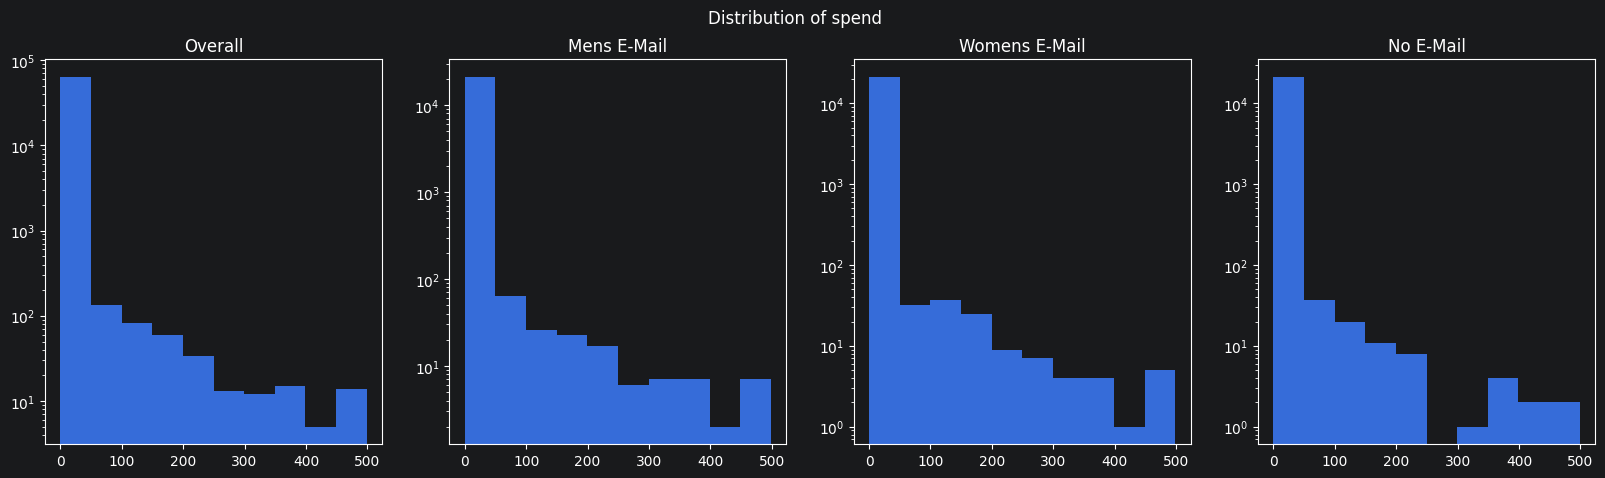

Overall Cross-Tab: 0.0615286352991271
Men Cross-Tab: 0.06856702619414484
Women Cross-Tab: 0.05836936380481779
Control Cross-Tab: 0.005726086548390125


In [43]:
# Exploring outcomes

conversion_rates = {
    "Overall Conversion": df["conversion"].sum() / df["conversion"].count(),
    "Men Conversion": df_men_email["conversion"].sum() / df_men_email["conversion"].count(),
    "Women Conversion": df_women_email["conversion"].sum() / df_women_email["conversion"].count(),
    "Control Conversion": df_no_email["conversion"].sum() / df_no_email["conversion"].count()
}
for key, value in conversion_rates.items(): print(f"{key}: {value}")
print(f"Unmodeled Uplift: {conversion_rates["Men Conversion"] - conversion_rates["Control Conversion"]}\n")

visit_rates = {
    "Overall Visit": df["visit"].sum() / df["visit"].count(),
    "Men Visit": df_men_email["visit"].sum() / df_men_email["visit"].count(),
    "Women Visit": df_women_email["visit"].sum() / df_women_email["visit"].count(),
    "Control Visit": df_no_email["visit"].sum() / df_no_email["visit"].count()
}
for key, value in visit_rates.items(): print(f"{key}: {value}")

# View distribution of spending
compare_dists("spend", log=True)

cross_tab_rates = {
    "Overall Cross-Tab": df["conversion"].sum() / df["visit"].sum(),
    "Men Cross-Tab": df_men_email["conversion"].sum() / df_men_email["visit"].sum(),
    "Women Cross-Tab": df_women_email["conversion"].sum() / df_women_email["visit"].sum(),
    "Control Cross-Tab": df_no_email["conversion"].sum() / df_no_email["visit"].count()
}
for key, value in cross_tab_rates.items(): print(f"{key}: {value}")

(6, 9]: 0.007900480967920703
(0, 3]: 0.007326383487528679
(3, 6]: 0.005030460878328993
(9, 12]: 0.0066521136039852605


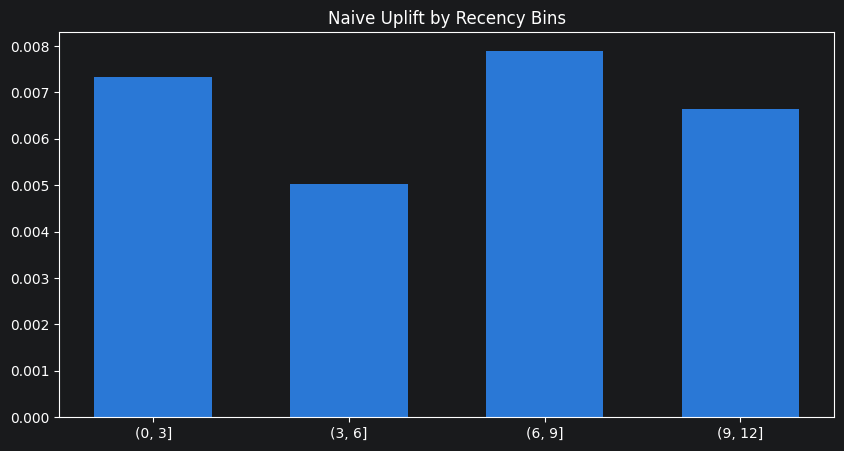

In [71]:
# Naive uplift for recency
edges = [0, 3, 6, 9, 12]
df_men_email["recency_bins"] = pd.cut(df_men_email["recency"], bins=edges)
df_no_email["recency_bins"] = pd.cut(df_no_email["recency"], bins=edges)
recency_uplift = {}
for bin in df_men_email["recency_bins"].unique():
    men_mask = df_men_email["recency_bins"] == bin
    men_conversion_rate = df_men_email[men_mask]["conversion"].mean()
    control_mask = df_no_email["recency_bins"] == bin
    control_conversion_rate = df_no_email[control_mask]["conversion"].mean()
    recency_uplift[bin] = men_conversion_rate - control_conversion_rate

for key, value in recency_uplift.items(): print(f"{key}: {value}")

sorted_items = sorted(recency_uplift.items(), key=lambda kv: kv[0].left)
labels = [str(bin) for bin, _ in sorted_items]
uplift_values = [value for _, value in sorted_items]

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Naive Uplift by Recency Bins")
bars = ax.bar(labels, uplift_values, color=colors, width=0.6)
plt.show()